<a href="https://colab.research.google.com/github/shakthyy30/shakthyy-codebooster-2026/blob/main/MiniProjectDay9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install groq -q
print("Libraries installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 5.1 MB/s eta 0:00:00
Libraries installed successfully


In [ ]:
import sqlite3
import pandas as pd
import os
from groq import Groq
import re

print("All libraries imported successfully")

All libraries imported successfully


In [ ]:
import os
os.environ["GROQ_API_KEY"]="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"
Client=Groq(api_key=os.environ["GROQ_API_KEY"])
MODEL="llama-3.1-8b-instant" # Corrected typo here
print("Done")

# Removed the redundant and incorrect reassignment
# MODEL ="llma-3.1-8b-instant"
print("Groq client intialized Successfully")
print(f"Using model: {MODEL}")

Done
Groq client intialized Successfully
Using model: llama-3.1-8b-instant


In [ ]:
import io
df=pd.read_csv('student_performance.csv')

print(f"Database loaded:{df.shape[0]}row,{df.shape[1]}columns")
print(f"columns:{df.columns.tolist()}")
print("\nFirst 3 rows:")
df.head(3)


Database loaded:30row,13columns
columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [ ]:
conn = sqlite3.connect("college.db")
df.to_sql("students",conn,if_exists="replace",index=False)
test_df=pd.read_sql("select count(*) as attend from students where attendance_percentage > 90",conn)
print(f"verification:{test_df['attend'][0]} rows")

verification:10 rows


In [ ]:
conn=sqlite3.connect("college.db")
print("Database created:college.db")

# Create the 'students' table and insert data from the 'df' DataFrame
df.to_sql('students', conn, if_exists='replace', index=False)

print("Table 'students' created with 30 student records")
test_df=pd.read_sql_query("SELECT COUNT(*) as total_rows FROM students",conn)
print(f"\n Verification:{test_df['total_rows'][0]}rows in database ")

Database created:college.db
Table 'students' created with 30 student records

 Verification:30rows in database 


In [ ]:
def get_schema(conn , table_name = "students"):
  """
  This is the description for you
  """
  cursor = conn.cursor()
  cursor.execute(f"PRAGMA table_info({table_name})")
  columns = cursor.fetchall()
  schema_lines =[f"Table :{table_name}"]
  schema_lines.append("columns :")
  for col in columns :
    schema_lines.append(f" - {col[1]} ({col[2]})")

  cursor.execute(f"SELECT * FROM {table_name} LIMIT 3")
  sample_rows = cursor.fetchall()
  schema_lines.append("\nSample rows (first 3 ): ")

  for row in sample_rows :
    schema_lines.append(f" - {row}")
  return "\n".join(schema_lines)

schema = get_schema(conn)
print(schema)

Table :students
columns :
 - student_id (INTEGER)
 - name (TEXT)
 - age (INTEGER)
 - gender (TEXT)
 - department (TEXT)
 - semester (INTEGER)
 - math_score (INTEGER)
 - science_score (INTEGER)
 - english_score (INTEGER)
 - programming_score (INTEGER)
 - attendance_percentage (INTEGER)
 - city (TEXT)
 - admission_year (INTEGER)

Sample rows (first 3 ): 
 - (1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023)
 - (1002, 'Priya Patel', 20, 'Female', 'Computer Science', 2, 76, 82, 88, 79, 87, 'Ahmedabad', 2023)
 - (1003, 'Rohit Verma', 19, 'Male', 'Electronics', 2, 65, 74, 61, 55, 78, 'Delhi', 2023)


In [ ]:
system_prompt = f"""
You are an elite SQL Database Assistant and Data Analyst.

You are connected to a SQLite database with the following schema:

{schema}

Your responsibilities:
1. Understand the user's question in natural language.
2. Generate accurate SQLite-compatible SQL queries.
3. Use only tables and columns that exist in the provided schema.
4. Never assume columns or tables that are not present.
5. If the user's request is ambiguous, ask for clarification before generating SQL.
6. Always optimize queries for readability and performance.
7. Use LIMIT when displaying large datasets unless explicitly requested otherwise.
8. When performing aggregations, provide meaningful aliases.
9. Explain the generated SQL query in simple terms before execution.
10. After receiving query results, provide a concise and insightful analysis.

Rules:
- Output only valid SQLite SQL.
- Never generate destructive queries such as DROP, DELETE, TRUNCATE, ALTER, or UPDATE unless explicitly authorized.
- Never modify the database structure.
- Always validate table and column names against the schema.
- If a request cannot be answered using the available schema, clearly state why.
- Prefer parameterized query patterns when user input is involved.
- Use JOINs only when necessary.
- Handle NULL values appropriately.
"""

# Define user_question as a placeholder
user_question = ""

response=Client.chat.completions.create(model=MODEL,messages=[{"role":"system","content":system_prompt},{"role":"user","content":user_question}])
print(response.choices[0].message.content)

You can use me to ask any questions about the database. What would you like to know about the students in the database?


In [ ]:
def generate_sql(user_question, schema_text, client, model):
    """
    Generate SQLite SQL query from natural language question.
    """

    system_prompt = f"""
You are an elite SQL Database Assistant.

You are connected to a SQLite database with the following schema:

{schema_text}

Instructions:
- Convert the user's question into a valid SQLite query.
- Use ONLY the tables and columns available in the schema.
- Do NOT invent tables or columns.
- Generate ONLY the SQL query.
- Do NOT provide explanations.
- Do NOT use markdown code blocks.
- Do NOT generate DROP, DELETE, UPDATE, ALTER, or TRUNCATE statements.
- Use LIMIT 10 for large result sets unless the user specifies otherwise.
"""

    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "system",
                "content": system_prompt
            },
            {
                "role": "user",
                "content": user_question
            }
        ],
        temperature=0.0
    )

    sql_query = response.choices[0].message.content.strip()


    return sql_query

question="show me Aarav Sharma details"
print(generate_sql(question,schema,Client,MODEL))

SELECT * FROM students WHERE name = 'Aarav Sharma'


In [ ]:
question="show me all female students"
print(f"Question: {question}")
print("\nGenerated SQL....")
sql=generate_sql(question,schema,Client,MODEL)
print(f"\nGenerated SQL:\n{sql}")

Question: show me all female students

Generated SQL....

Generated SQL:
SELECT * FROM students WHERE gender = 'Female'


In [ ]:
def execute_sql(sql_query,conn):
  clean_sql=sql_query.strip()
  clean_sql=re.sub(r'```sql\s*','',clean_sql)
  clean_sql=re.sub(r'```\s*','',clean_sql)
  clean_sql=clean_sql.strip()

  try:
    result_df=pd.read_sql(clean_sql,conn)
    return result_df,None
  except Exception as e:
    return str(e)


Plotting for: show me all students with attendance percentage greater than 90
Generated SQL for plot:
SELECT * FROM students WHERE attendance_percentage > 90 LIMIT 10


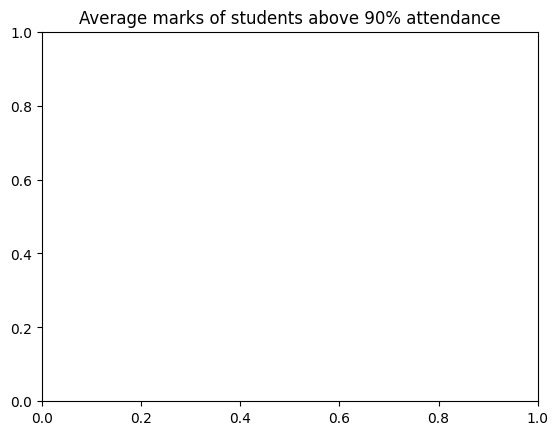

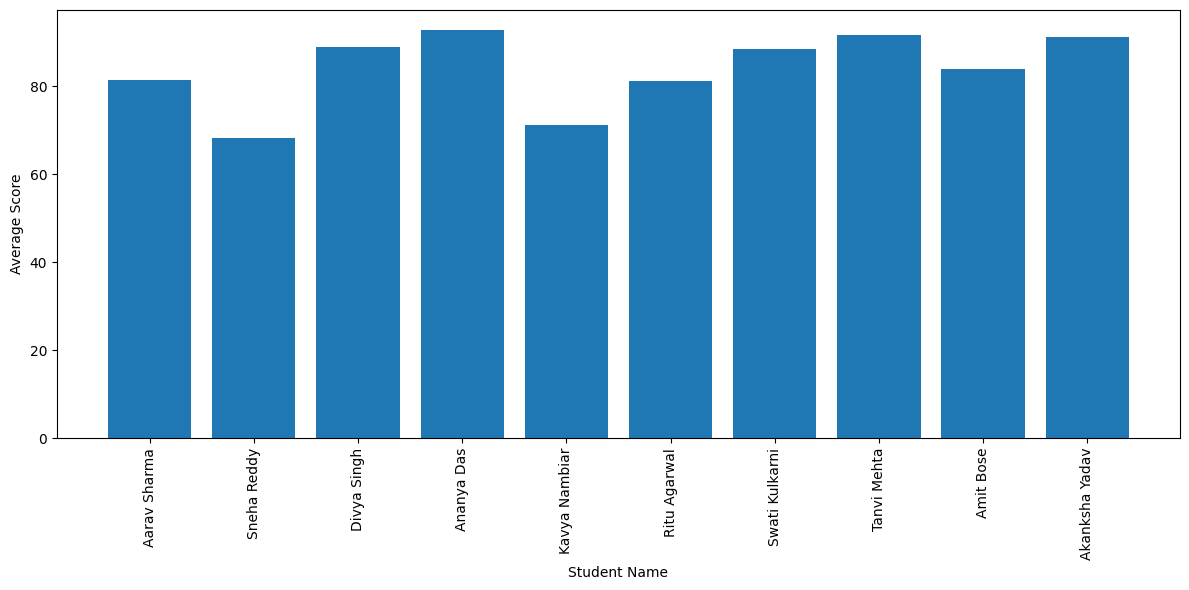

In [ ]:
import matplotlib.pyplot as plt

# Define the question for the data needed for the plot
plot_question = "show me all students with attendance percentage greater than 90"
print(f"Plotting for: {plot_question}")

# Generate the SQL query based on the plot_question
sql_for_plot = generate_sql(plot_question, schema, Client, MODEL)
print(f"Generated SQL for plot:\n{sql_for_plot}")

# Execute the SQL query and store the result in the 'result' variable
result, error = execute_sql(sql_for_plot, conn)

if error:
    print(f"Error executing SQL for plot: {error}")
elif result.empty:
    print("No data to plot for students with attendance percentage greater than 90.")
else:
    plt.title("Average marks of students above 90% attendance")

    result['average_score'] = result[['english_score', 'math_score', 'programming_score', 'science_score']].mean(axis=1)

    plt.figure(figsize=(12, 6)) # Add a figure to better handle size
    plt.bar(result['name'], result['average_score'])
    plt.xlabel("Student Name")
    plt.ylabel("Average Score")
    plt.xticks(rotation=90)
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()


In [ ]:
def text_to_sql_agent(user_question, conn, client, model, verbose=True):

    print("=" * 60)
    print(f"User Question: {user_question}")
    print("=" * 60)

    # Step 1: Read Schema
    if verbose:
        print("\n[STEP 1] Reading database schema...")

    schema_text = get_schema(conn)

    if verbose:
        print("Schema loaded successfully.")

    # Step 2: Generate SQL
    if verbose:
        print("\n[STEP 2] Generating SQL query...")

    sql_query = generate_sql(
        user_question,
        schema_text,
        client,
        model
    )

    if verbose:
        print(f"\nGenerated SQL:\n{sql_query}")

    # Step 3: Execute SQL
    if verbose:
        print("\n[STEP 3] Executing SQL query...")

    result_df, error = execute_sql(sql_query, conn)

    if error:
        print(f"\nError: {error}")

        return {
            "success": False,
            "sql_query": sql_query,
            "error": error
        }

    # Step 4: Show Results
    if verbose:
        print("\n[STEP 4] Query executed successfully.")
        print(f"Rows returned: {len(result_df)}")

    return {
        "success": True,
        "sql_query": sql_query,
        "result": result_df
    }

In [ ]:
df = text_to_sql_agent(
    "Show all electronics student",
    conn,
    Client,
    MODEL
)

display(df)

User Question: Show all electronics student

[STEP 1] Reading database schema...
Schema loaded successfully.

[STEP 2] Generating SQL query...

Generated SQL:
SELECT * FROM students WHERE department = 'Electronics'

[STEP 3] Executing SQL query...

[STEP 4] Query executed successfully.
Rows returned: 6


{'success': True,
 'sql_query': "SELECT * FROM students WHERE department = 'Electronics'",
 'result':    student_id           name  age  gender   department  semester  math_score  \
 0        1003    Rohit Verma   19    Male  Electronics         2          65   
 1        1006    Meera Joshi   20  Female  Electronics         2          58   
 2        1011    Vikram Iyer   20    Male  Electronics         2          80   
 3        1016   Ritu Agarwal   20  Female  Electronics         2          87   
 4        1021  Harish Pillai   20    Male  Electronics         2          64   
 5        1026     Rekha Nair   20  Female  Electronics         2          72   
 
    science_score  english_score  programming_score  attendance_percentage  \
 0             74             61                 55                     78   
 1             66             70                 52                     72   
 2             75             68                 72                     83   
 3             83 

In [16]:
def dataframe_to_nl(
    user_question,
    result_df,
    client,
    model
):

    prompt = f"""
User Question:
{user_question}

Database Result:
{result_df.to_string(index=False)}

Convert the database result into a natural language answer.

Rules:
- Answer the user's question directly.
- Be concise and professional.
- Explain the result in plain English.
"""

    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "system",
                "content": "You are an expert data analyst."
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0.3
    )

    return response.choices[0].message.content

# Assuming 'df' contains the dictionary result from text_to_sql_agent
# and that the last user question for that agent call was "Show all electronics student"
user_question_for_nl = "Show all electronics student"
result_dataframe_for_nl = df['result']

nl_output = dataframe_to_nl(
    user_question_for_nl,
    result_dataframe_for_nl,
    Client,
    MODEL
)

print("Natural Language Output:")
print(nl_output)

Natural Language Output:
There are 6 electronics students in the database. Here are their details:

1. Rohit Verma, a 19-year-old male from Delhi, is in his 2nd semester with a math score of 65, science score of 74, and programming score of 55.
2. Meera Joshi, a 20-year-old female from Pune, is also in her 2nd semester with a math score of 58, science score of 66, and programming score of 52.
3. Vikram Iyer, a 20-year-old male from Chennai, is in his 2nd semester with a math score of 80, science score of 75, and programming score of 72.
4. Ritu Agarwal, a 20-year-old female from Agra, is in her 2nd semester with a math score of 87, science score of 83, and programming score of 69.
5. Harish Pillai, a 20-year-old male from Thiruvananthapuram, is in his 2nd semester with a math score of 64, science score of 70, and programming score of 58.
6. Rekha Nair, a 20-year-old female from Kochi, is in her 2nd semester with a math score of 72, science score of 77, and programming score of 63.
